In [ ]:
import time
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image
import os
import sys
sys.path.append(os.path.dirname(os.getcwd()))
from pc import PS
from modules import ADC,DAC,CHIP
from command import CMD,CmdData,Packet
from command.singleCmdInfo import *

from util import plot_v_cond,plot_cond,show_crossbar,DataLoader

from network.layer import Layer

In [ ]:
chip=CHIP(PS(host="192.168.1.10", port = 7, debug=0),init=True)
chip.set_device_cfg(deviceType=0)
chip.adc.set_gap(adc_cs_gap=100,adc_first_gap=20,adc_last_gap=20)
chip.adc.set_gain_resistor(big_resistance=22e-3,small_resistance=200)
chip.clk_manager.set_cyc(delay1=20,delay2=50)
chip.add_compiler("../compiler/code/")
chip.compensation.initop("../modules/data/chip_1_4/")

In [ ]:
weight = np.load("../data/hnn/w_matrix_7_7.npy")
hnnLayer = []
for i in range(7):
    layer=Layer(chip=chip,weight_target=weight[:,i*7:(i+1)*7],weight_min=-0.19,weight_max=0.19,cond_min=0,cond_max=1100,cond_reference=550)
    layer.set_weight_map_form_file(f"../data/hnn/hnn_weight_49_7_{i}.npz")
    hnnLayer.append(layer)

In [ ]:
tg_map = np.array([1.5,1.55,1.6,1.65,1.7,1.75,1.8])
cond_map = np.array([350,390,450,490,550,590,650])
slope,intercept = np.polyfit(cond_map,tg_map, 1)

# 2.写权重

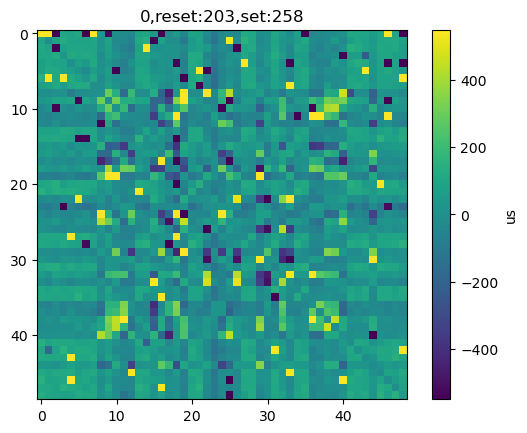

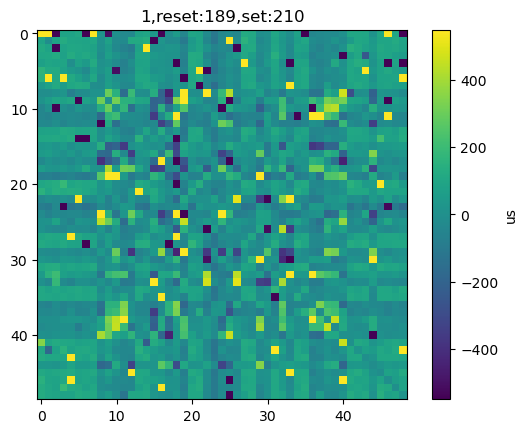

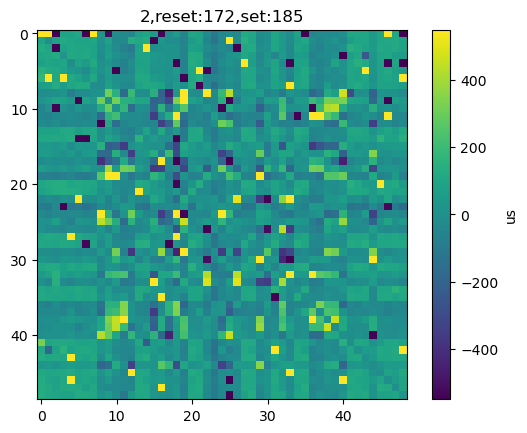

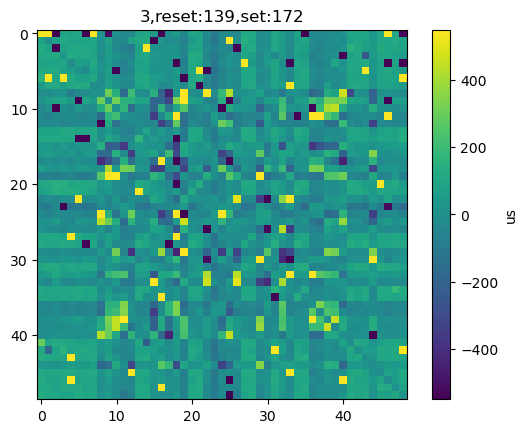

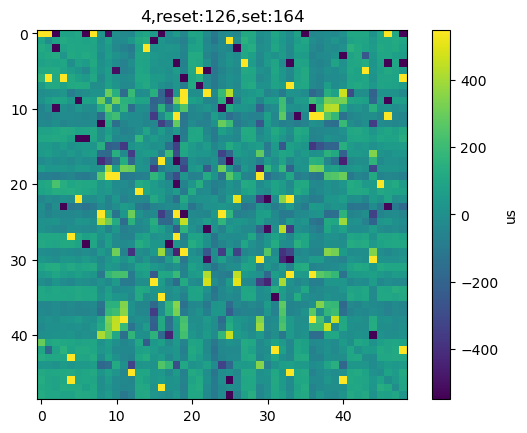

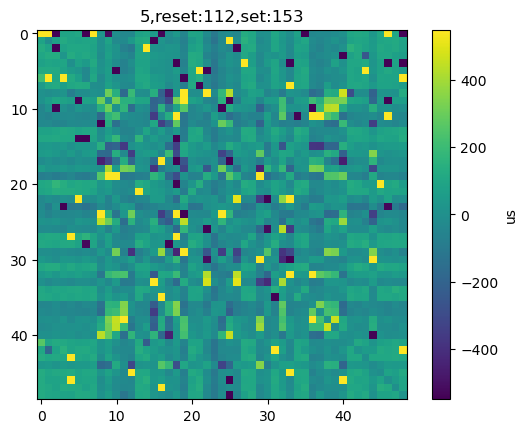

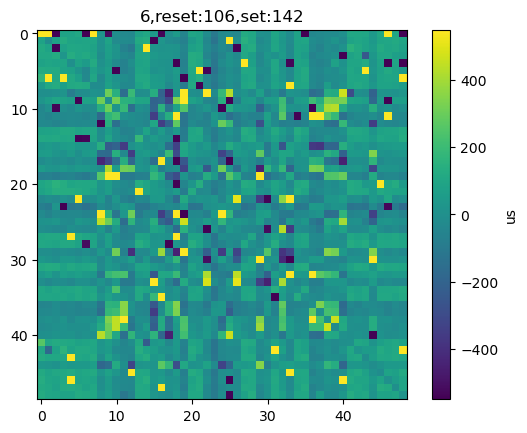

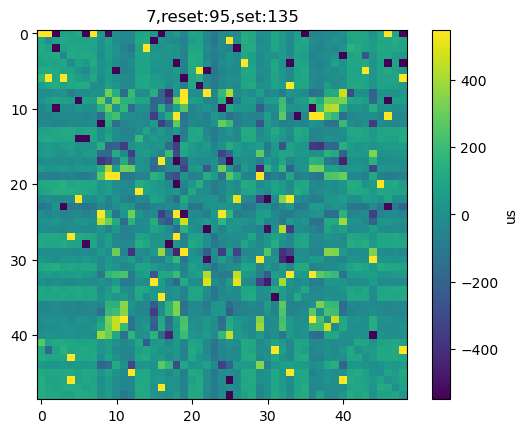

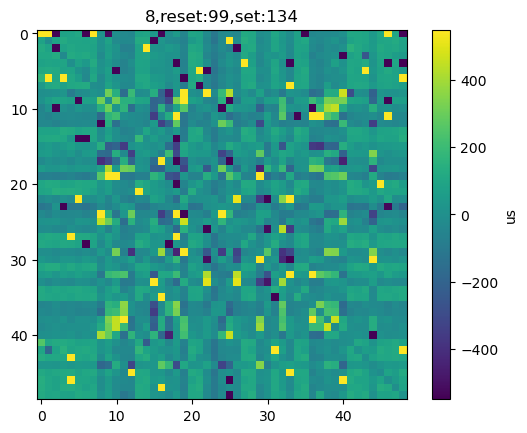

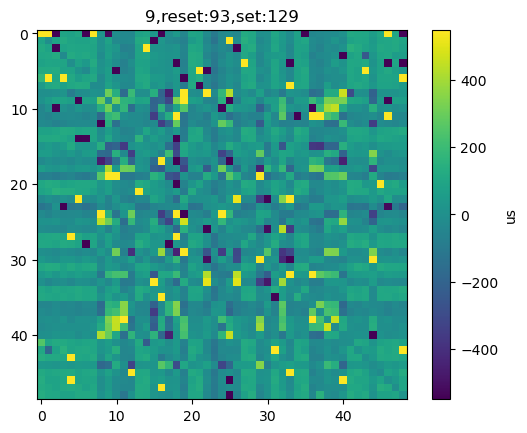

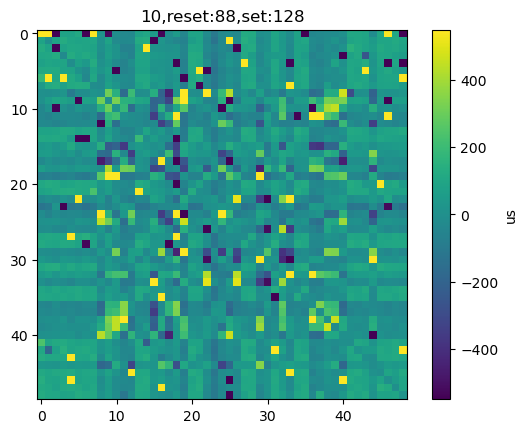

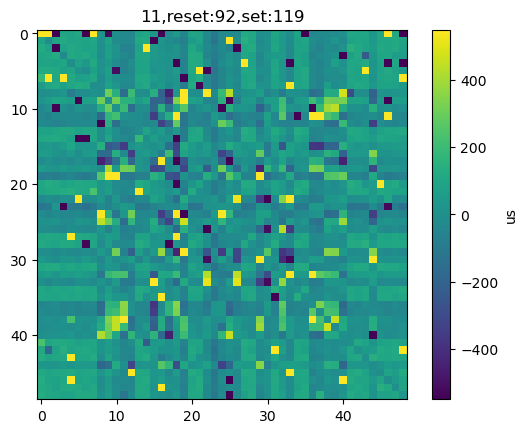

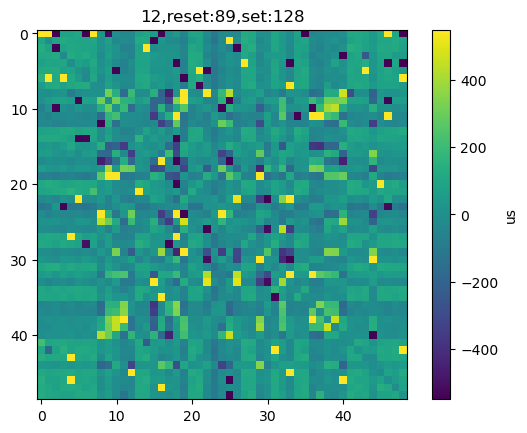

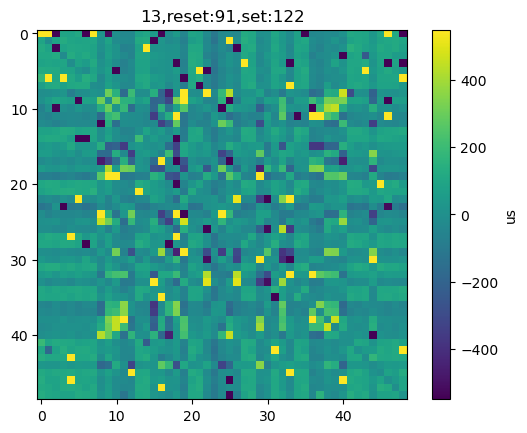

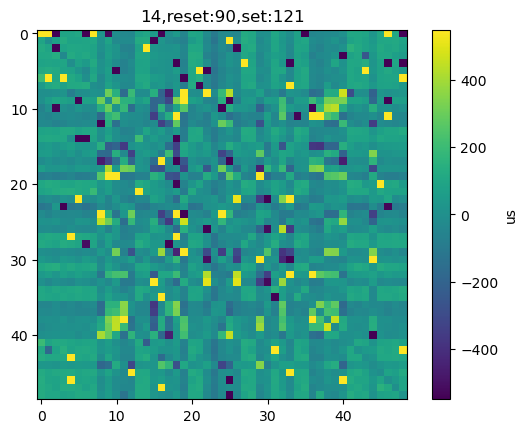

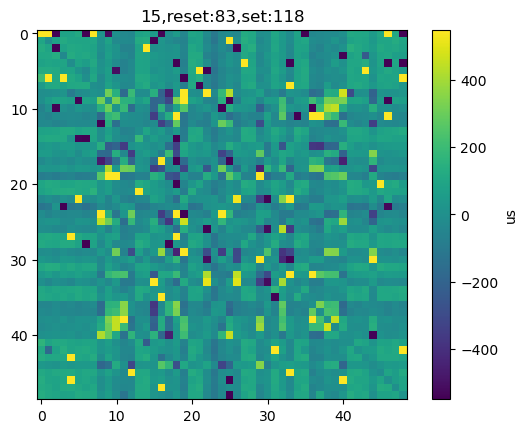

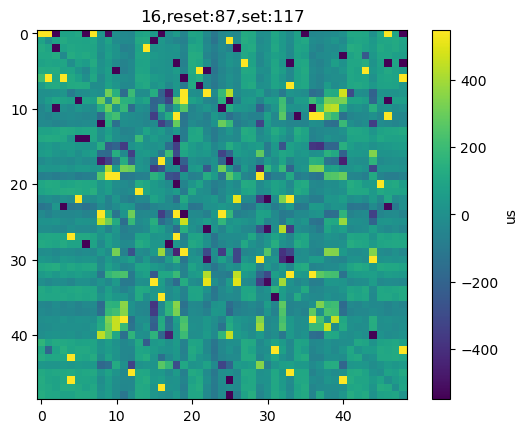

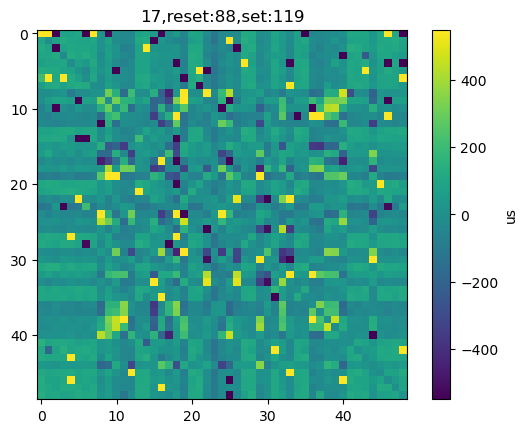

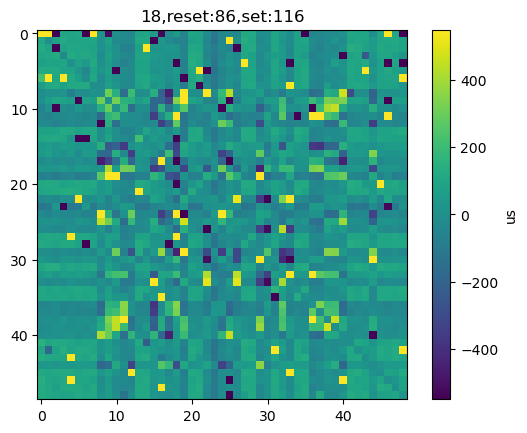

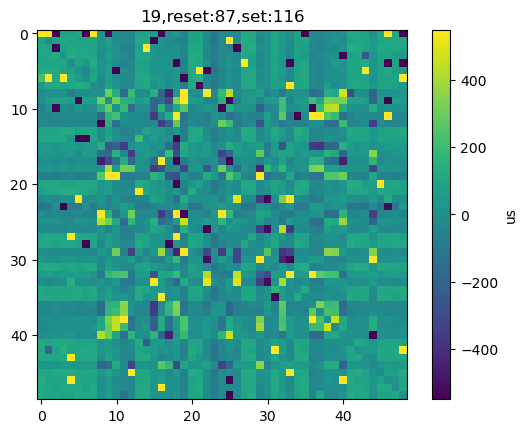

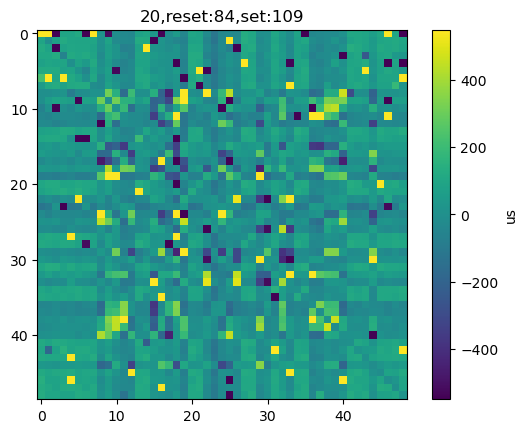

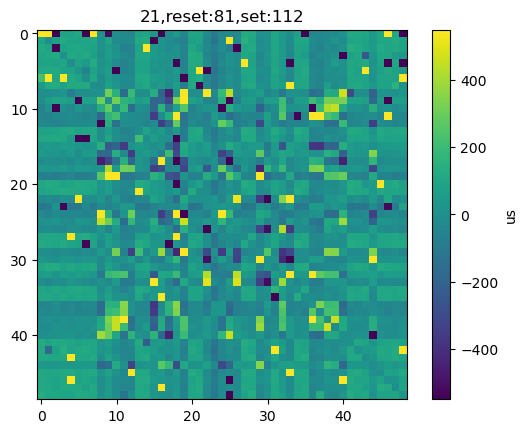

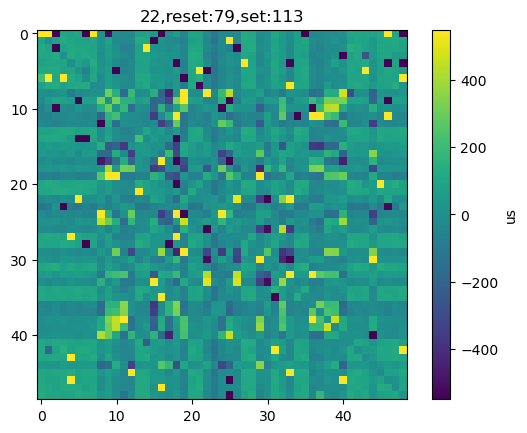

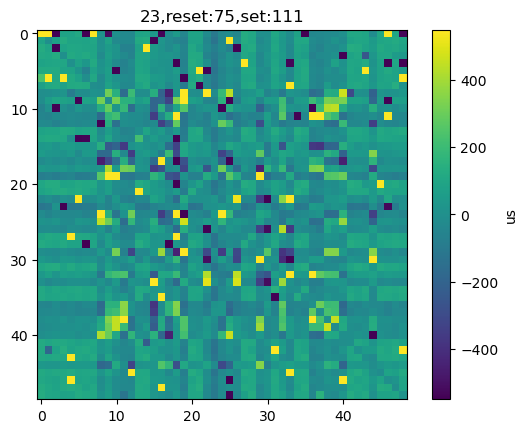

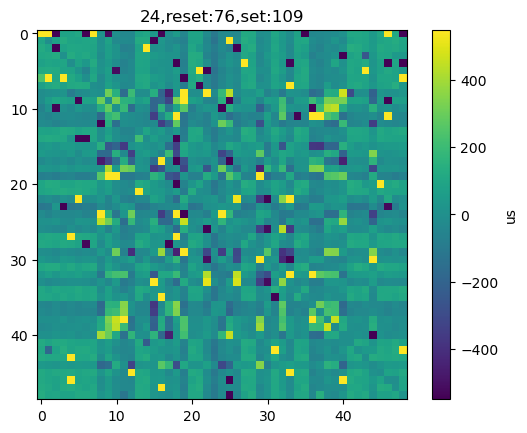

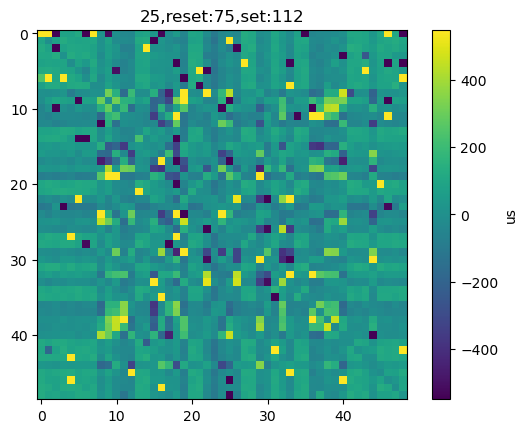

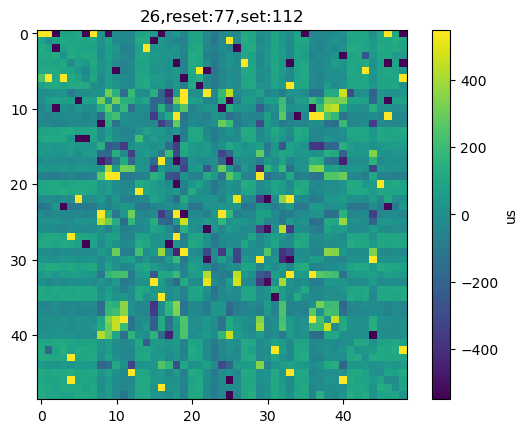

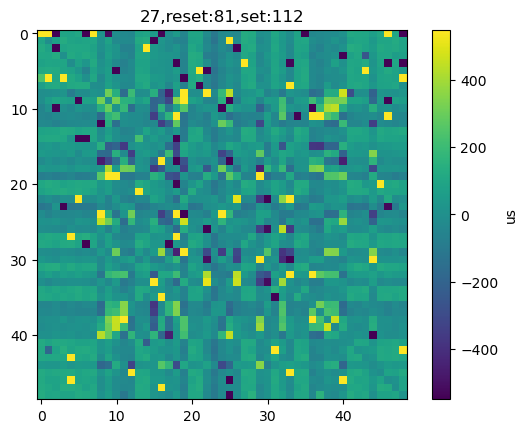

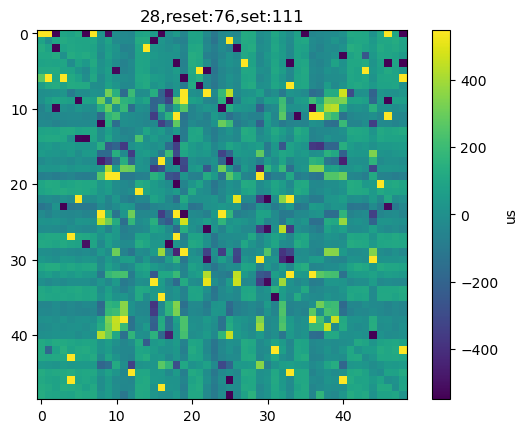

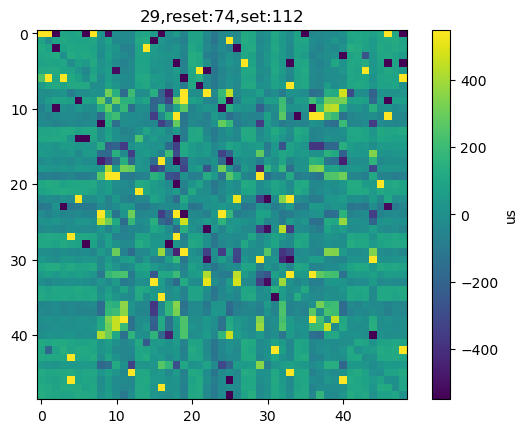

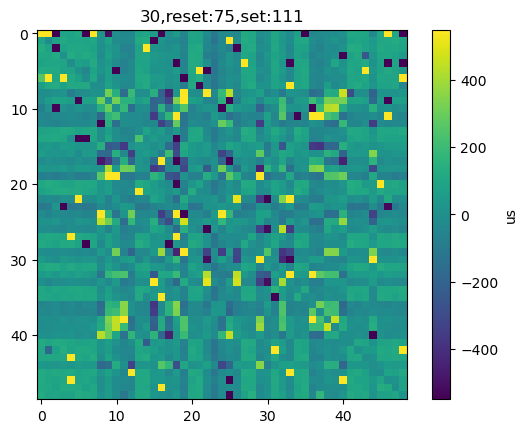

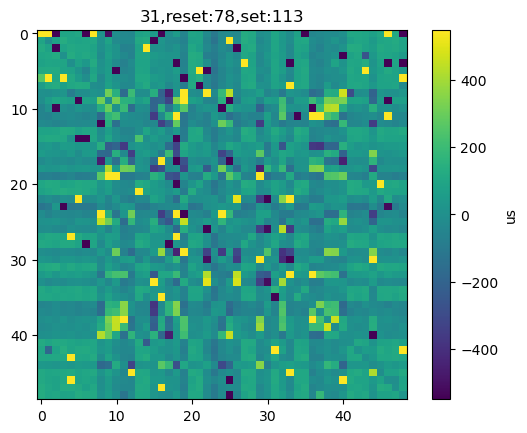

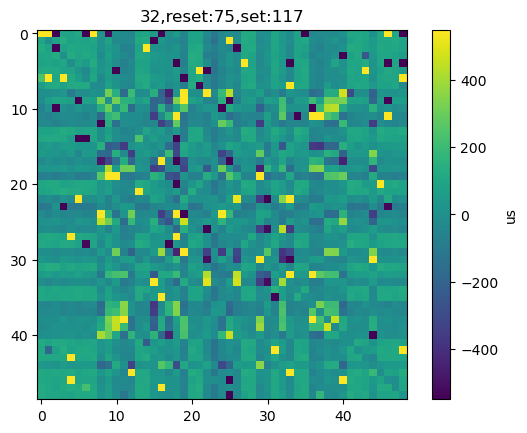

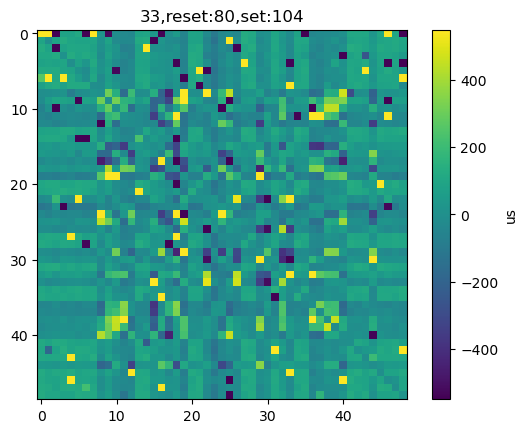

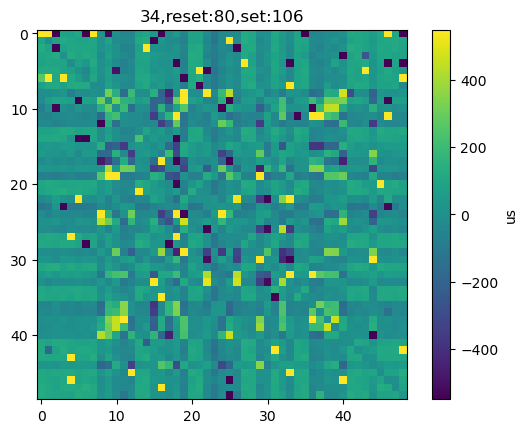

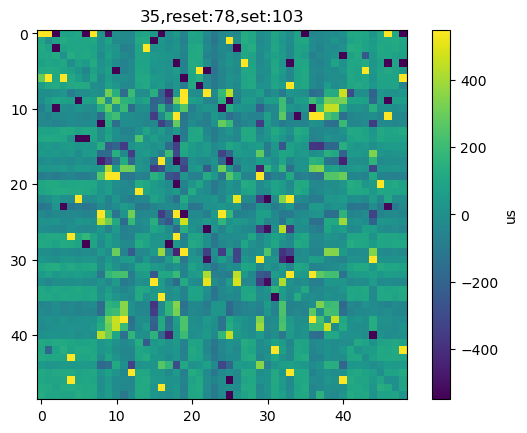

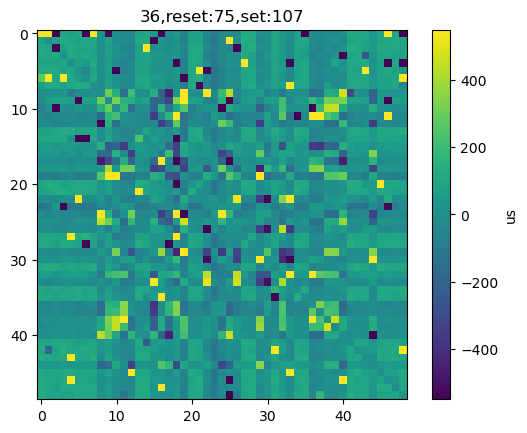

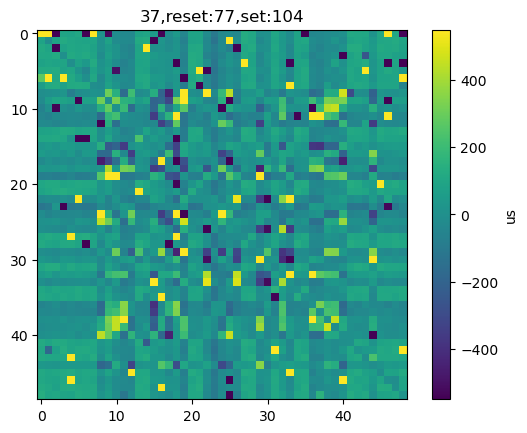

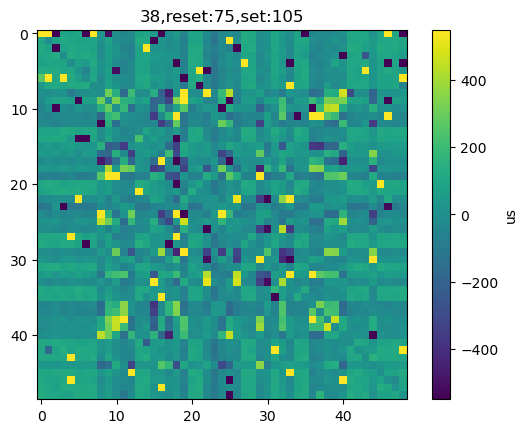

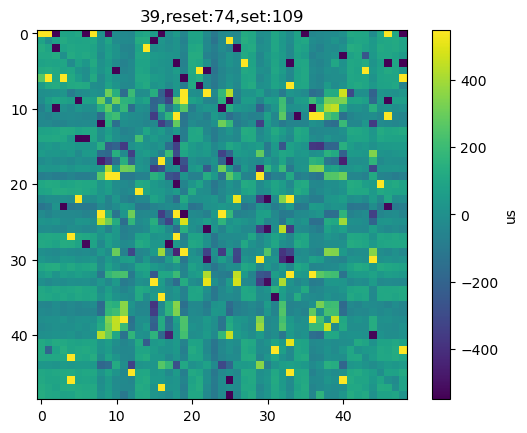

In [65]:
threshold = 30

set_v,reset_v = 1,1
reset_pulse_width,set_pulse_width = 100e-6,100e-6
need_read = np.zeros((256,256),dtype=bool)
target = np.ones((256,256))

for i in range(7):
    pos = hnnLayer[i].get_weight_pos()
    need_read[pos] = True
    target[pos] = hnnLayer[i].get_target_cond()

tg_v = target*slope+intercept
for k in range(1):
    for i in range(40):
        voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
        voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
        resistence = chip.voltage_to_resistance(voltage = voltage-voltage_base)
        cond = chip.compensation.compensation_point(resistence=resistence,from_row=True,return_type=0)

        condition_reset = (cond > (target+threshold)) & need_read
        condition_set = (cond < (target-threshold)) & need_read
        cond_show = np.zeros((49,49))
        for j in range(7):
            pos = hnnLayer[j].get_weight_pos()
            cond_show[:,j*7:(j+1)*7]=cond[pos]
        plot_cond(cond_show-hnnLayer[0].cond_reference,vmin=-hnnLayer[0].cond_range,vmax=hnnLayer[0].cond_range,title=f"{i},reset:{np.sum(condition_reset)},set:{np.sum(condition_set)}")

        if i>0:
            # set_v+=0.05
            # reset_v+=0.05
            # tg_v[condition_set] +=0.05
            if i<10:
                tg_v[condition_reset] -= 0.04
                tg_v[condition_set] += 0.04
            else:
                tg_v[condition_reset] -= 0.02
                tg_v[condition_set] += 0.02

        tg_v.clip(0,5,out=tg_v)

        chip.write_point2(crossbar=condition_reset,write_voltage=reset_v,tg=5,pulse_width=reset_pulse_width,set_device=False)
        chip.write_point2(crossbar=condition_reset,write_voltage=set_v,tg=tg_v,pulse_width=set_pulse_width,set_device=True)
        # # # # chip.ps.set_time_out(100)
        chip.write_point2(crossbar=condition_set,write_voltage=set_v,tg=tg_v,pulse_width=set_pulse_width,set_device=True)

    set_v = set_v+0.1
    reset_v = reset_v+0.05
    set_pulse_width = set_pulse_width+10e-6*k
    reset_pulse_width = reset_pulse_width+10e-6*k
    tg_v = target*slope+intercept+k*0.05-0.3

# 3.测试读出来的权重推理效果

In [66]:
# cond = hnnLayer.read_cond_point(from_row=True)
# W = hnnLayer.read_weight_point(from_row=True)
cond = np.zeros((49,49))
for j in range(7):
    cond_tmp = hnnLayer[j].read_cond_point(from_row=True)
    pos = hnnLayer[j].get_weight_pos()
    cond[:,j*7:(j+1)*7]=cond_tmp

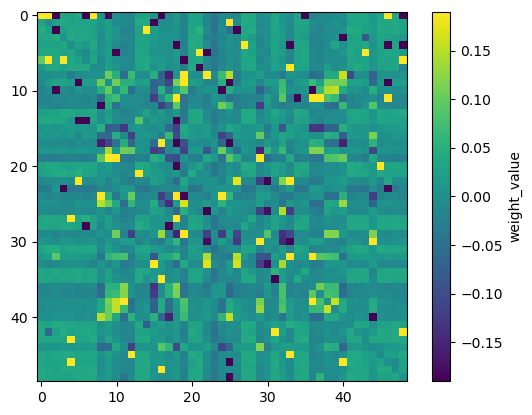

In [68]:
W = (cond-hnnLayer[0].cond_reference)/hnnLayer[0].cond_range*hnnLayer[0].weight_max
# W[W>0.19]=-0.19
plot_cond(W,vmin=-hnnLayer[0].weight_max,vmax=hnnLayer[0].weight_max,label="weight_value")
# plot_cond(W-hnnLayer[0].weight_target,vmin=-hnnLayer[0].weight_max,vmax=hnnLayer[0].weight_max,label="weight_value")
# plot_cond(target_cond,vmin=-cond_range,vmax=cond_range,label="cond")
# plot_cond(hnnLayer[0].map_cond-(cond-hnnLayer[0].cond_reference),vmin=-50,vmax=50,label="cond")

# 4.片上推理测试

In [ ]:
ans = hnnLayer.calculate_error_from_row(hnnLayer.row_index,[hnnLayer.col_index[12]],value=0.875,compensation_type=0,real_mean=400)
plt.plot(ans[:,0],label = "real")
plt.plot(ans[:,1],label = "Compensation1")
plt.title("col="+str(hnnLayer.col_index[1]))
plt.ylabel("uS")
plt.xlabel("row nums")
plt.legend()
plt.show()

In [ ]:
hnnLayer.set_forward_paramater(forward_type=2,interval=100,value=0.78)
cond2 = hnnLayer.forward_unsigned_from_row(hnnLayer.row_index[:25],hnnLayer.col_index,forward_type=2,value=0.78,return_type=2)
cond0 = hnnLayer.forward_unsigned_from_row(hnnLayer.row_index[:25],hnnLayer.col_index,forward_type=3,value=0.875,return_type=2)

In [ ]:
for i in range(49):
    print(cond0[i],cond2[i],cond0[i]-cond2[i],hnnLayer.col_index[i])

In [69]:
imgs=np.load("../data/hnn/imgs.npy")
steps=10
# hnnLayer.set_forward_paramater(forward_type=2,interval=25,value=0.875)

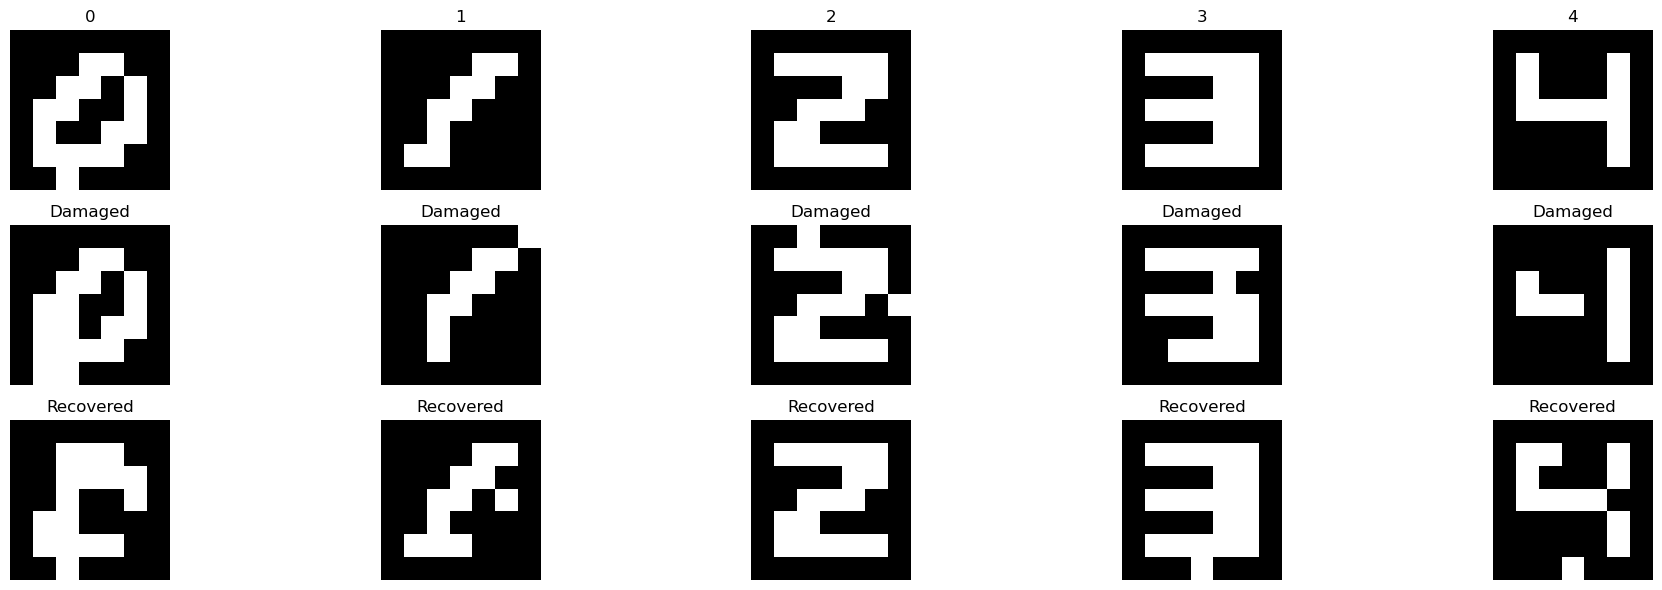

In [71]:
net_size = 49  # 例如 100 表示 10×10
num_imgs = 5
side = int(np.sqrt(net_size))  # 图像边长


processed_patterns = [np.where(img > 0, 1, -1) for img in imgs]

def hopfield_recall_sync(state, W, steps=10000):
    """
    state: 初始状态（side x side，取值 +1 或 -1）
    W: 训练好的权重矩阵
    steps: 最大更新次数
    返回: 收敛后的状态（side x side）

    采用同步更新：每一步计算所有神经元的新状态，然后同时更新
    """
    state_flat = state.flatten()
    for _ in range(steps):
        # 同步计算所有神经元的净输入并更新状态
        # new_state = np.where(forward_from_row(hnnLayer,state_flat) >= 0, 1, -1)
        # new_state = np.where(hnnLayer.forward_from_row(state_flat) >= 0, 1, -1)
        new_state = np.where(np.dot(W, state_flat) >= 0, 1, -1)

        # 如果新状态与旧状态相同，则认为已收敛，退出循环
        if np.array_equal(new_state, state_flat):
            break
        state_flat = new_state
    return state_flat.reshape((state.shape))

# 5. 定义损坏函数（随机翻转像素）
def damage_pattern(pattern, damage_rate=0.3):
    """
    随机翻转一定比例 (damage_rate) 的像素
    """
    damaged = pattern.copy().flatten()
    N = damaged.size
    num_flip = int(damage_rate * N)
    flip_indices = np.random.choice(N, num_flip, replace=False)
    damaged[flip_indices] *= -1
    return damaged.reshape((side, side))

np.save("../data/hnn/processed_patterns.npy",processed_patterns)

# -----------------------------
# 6. 对每个数字测试：破坏后用 Hopfield 网络回忆
recovered_patterns = []
damaged_patterns = []
damage_rate = 0.05 # 例如翻转 30% 像素

for p in processed_patterns:
    damaged = damage_pattern(p, damage_rate)
    recovered = hopfield_recall_sync(damaged, W, steps=20)
    damaged_patterns.append(damaged)
    recovered_patterns.append(recovered)

fig, axes = plt.subplots(3, num_imgs, figsize=(20, 6))
for i in range(num_imgs):
    # 第一行：原始图像
    axes[0, i].imshow(processed_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[0, i].set_title(f"{i}")
    axes[0, i].axis('off')

    # 第二行：损坏图像
    axes[1, i].imshow(damaged_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[1, i].set_title("Damaged")
    axes[1, i].axis('off')

    # 第三行：回忆结果
    axes[2, i].imshow(recovered_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[2, i].set_title("Recovered")
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()
